In [1]:
import pandas as pd
import os


from utils.utils import PolicyEDA, EmissionsDataProcessor

/home/tony-ubuntu/anaconda3/envs/cpa_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = PolicyEDA()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [5]:
# import IEA scored data
policy_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_scored_cpsi.csv"))
policy_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752


In [6]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9255 entries, 0 to 9254
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        9255 non-null   object 
 1   year               9255 non-null   int64  
 2   avg_policy_score   9255 non-null   float64
 3   policy_count       9255 non-null   int64  
 4   dominant_topic     9255 non-null   object 
 5   dominant_category  9255 non-null   object 
 6   log_policy_count   9255 non-null   float64
 7   CPSI               9255 non-null   float64
 8   CPSI_power_3       9255 non-null   float64
 9   CPSI_geom_4        9255 non-null   float64
 10  CPSI_geom_7        9255 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 795.5+ KB


In [7]:
# import emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions_db.csv"))
emissions_df.head()

,iso_alpha_3,income_group,year,total_emissions
0,ABW,High income,2000,0.335765
1,ABW,High income,2001,0.344135
2,ABW,High income,2002,0.363222
3,ABW,High income,2003,0.412246
4,ABW,High income,2004,0.430187


In [8]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   year             4485 non-null   int64  
 3   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 140.3+ KB


In [9]:
# import wb controls
wb_controls_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_control_vars.csv"))
wb_controls_df.head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
0,2022,1.040350e+12,731821393.0,565.488909,NaN,7.303970,37.909012,26.921919,29.737205,NaN
1,2021,1.004646e+12,713090928.0,570.998888,NaN,7.156658,37.393633,26.075267,29.955194,NaN
2,2020,9.606813e+11,694446100.0,563.976201,66.123449,7.107927,36.884034,25.434235,30.174252,NaN
3,2019,9.890095e+11,675950189.0,586.441491,63.387090,7.212707,36.384272,26.421751,30.391626,NaN
4,2018,9.677734e+11,657801085.0,583.763039,62.242631,7.273489,35.893398,27.859732,30.611512,NaN


In [10]:
wb_controls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               6118 non-null   int64  
 1   gdp_2015_usd       5832 non-null   float64
 2   population         6095 non-null   float64
 3   energy_per_capita  4565 non-null   float64
 4   renewable_share    5710 non-null   float64
 5   energy_intensity   4404 non-null   float64
 6   urbanization_rate  6049 non-null   float64
 7   industry_size      5551 non-null   float64
 8   forest_area        5953 non-null   float64
 9   iso_alpha_3        4945 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 478.1+ KB


In [11]:
global_policy_emissions_df = pd.merge(policy_df, emissions_df, on=["iso_alpha_3", "year"], how="inner")
global_policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,total_emissions
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,25.390391
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,23.723115
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,26.383509
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,27.071538
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,27.128799


In [12]:
# check if USA is in the data
global_policy_emissions_df[global_policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,total_emissions
3965,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,4.317488,1.983711,9.446749,16.263613,27.070635,High income,6318.595153
3966,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,4.418841,2.034283,10.106958,17.469706,29.368590,High income,6237.645614
3967,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,4.553877,2.034711,10.700017,19.030183,32.523942,High income,6102.809992
3968,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,4.644391,2.062921,11.271911,20.239021,34.925083,High income,6142.901629
3969,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,4.779123,2.207307,12.772495,22.502834,39.204911,High income,6313.734481


In [13]:
# Safety check to ensure USA is in the data
wb_controls_df[wb_controls_df["iso_alpha_3"] == "USA"].head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
5865,2022,2.144339e+13,333271411.0,6520.176697,NaN,11.171772,83.084,NaN,33.866926,USA
5866,2021,2.091785e+13,332048977.0,6441.742879,10.9,11.071275,82.873,17.608172,33.866926,USA
5867,2020,1.972358e+13,331526933.0,6138.375293,11.0,10.972348,82.664,17.267677,33.866926,USA
5868,2019,2.015964e+13,328329953.0,6736.457903,10.2,10.318741,82.459,18.145484,33.866926,USA
5869,2018,1.965187e+13,326838199.0,6770.788961,9.9,10.053513,82.256,18.519546,33.866926,USA


In [14]:
# Now let's merge the wb controls data
global_policy_emissions_df = pd.merge(global_policy_emissions_df, wb_controls_df, on=["iso_alpha_3", "year"], how="inner")
global_policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,...,income_group,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,Low income,25.390391,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,Low income,23.723115,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,Low income,26.383509,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,Low income,27.071538,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,Low income,27.128799,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782


In [15]:
# check if USA is in the data
global_policy_emissions_df[global_policy_emissions_df["iso_alpha_3"] == "USA"].head()


,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,...,income_group,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
3943,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,4.317488,1.983711,9.446749,16.263613,...,High income,6318.595153,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174
3944,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,4.418841,2.034283,10.106958,17.469706,...,High income,6237.645614,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756
3945,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,4.553877,2.034711,10.700017,19.030183,...,High income,6102.809992,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338
3946,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,4.644391,2.062921,11.271911,20.239021,...,High income,6142.901629,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920
3947,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,4.779123,2.207307,12.772495,22.502834,...,High income,6313.734481,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502


In [16]:
## remove unnecessary columns
global_policy_emissions_df = global_policy_emissions_df.drop(columns=["avg_policy_score", 
                                                        "policy_count", 
                                                        "dominant_topic",
                                                        "dominant_category",
                                                        "income_group",
                                                        "log_policy_count"
                    ])

# move total_emissions to the end
global_policy_emissions_df = global_policy_emissions_df[[col for col in global_policy_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
global_policy_emissions_df.head()

,iso_alpha_3,year,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AFG,2000,0.51986,0.644646,1.490182,1.643752,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782,25.390391
1,AFG,2001,0.51986,0.644646,1.490182,1.643752,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115
2,AFG,2002,0.51986,0.644646,1.490182,1.643752,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509
3,AFG,2003,0.51986,0.644646,1.490182,1.643752,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538
4,AFG,2004,0.51986,0.644646,1.490182,1.643752,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799


In [17]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        4165 non-null   object 
 1   year               4165 non-null   int64  
 2   CPSI               4165 non-null   float64
 3   CPSI_power_3       4165 non-null   float64
 4   CPSI_geom_4        4165 non-null   float64
 5   CPSI_geom_7        4165 non-null   float64
 6   gdp_2015_usd       4092 non-null   float64
 7   population         4165 non-null   float64
 8   energy_per_capita  3353 non-null   float64
 9   renewable_share    4028 non-null   float64
 10  energy_intensity   3257 non-null   float64
 11  urbanization_rate  4165 non-null   float64
 12  industry_size      3994 non-null   float64
 13  forest_area        4126 non-null   float64
 14  total_emissions    4165 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 488.2+ KB


In [18]:
oecd_countries_iso3 = eda_utils.get_oecd_iso_codes()
oecd_policy_emissions_df = global_policy_emissions_df[global_policy_emissions_df["iso_alpha_3"].isin(oecd_countries_iso3)].reset_index(drop=True)
oecd_policy_emissions_df.head()

,iso_alpha_3,year,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AUS,2000,1.646963,5.745594,9.562867,14.737193,8.726517e+11,19028802.0,5681.228859,8.4,7.923112,84.235,24.550533,17.158156,581.422036
1,AUS,2001,1.868549,6.592434,10.105788,15.434088,8.903238e+11,19274701.0,5486.394559,8.4,8.263839,84.100,23.633521,17.128633,602.437642
2,AUS,2002,1.892528,6.823265,10.488593,16.109152,9.257550e+11,19495210.0,5480.234643,8.7,8.505064,84.222,23.611732,17.099111,606.209253
3,AUS,2003,2.119532,7.955850,11.544264,17.755269,9.543678e+11,19720737.0,5615.576756,7.2,8.458763,84.343,24.042096,17.069589,607.749769
4,AUS,2004,2.201468,9.152636,13.653080,21.591609,9.946831e+11,19932722.0,5652.130379,6.7,8.665917,84.463,23.934919,17.040066,608.183791


In [19]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        847 non-null    object 
 1   year               847 non-null    int64  
 2   CPSI               847 non-null    float64
 3   CPSI_power_3       847 non-null    float64
 4   CPSI_geom_4        847 non-null    float64
 5   CPSI_geom_7        847 non-null    float64
 6   gdp_2015_usd       847 non-null    float64
 7   population         847 non-null    float64
 8   energy_per_capita  847 non-null    float64
 9   renewable_share    810 non-null    float64
 10  energy_intensity   847 non-null    float64
 11  urbanization_rate  847 non-null    float64
 12  industry_size      843 non-null    float64
 13  forest_area        846 non-null    float64
 14  total_emissions    847 non-null    float64
dtypes: float64(13), int64(1), object(1)
memory usage: 99.4+ KB


In [20]:
# safety check to ensure USA is in the data
oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
824,USA,2000,1.983711,9.446749,16.263613,27.070635,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174,6318.595153
825,USA,2001,2.034283,10.106958,17.469706,29.368590,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756,6237.645614
826,USA,2002,2.034711,10.700017,19.030183,32.523942,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338,6102.809992
827,USA,2003,2.062921,11.271911,20.239021,34.925083,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920,6142.901629
828,USA,2004,2.207307,12.772495,22.502834,39.204911,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502,6313.734481


## Data Cleaning

In [21]:
feats_to_keep = ["iso_alpha_3", "year", "CPSI_geom_7", "gdp_2015_usd", "population", "total_emissions"]
global_policy_emissions_df = global_policy_emissions_df[feats_to_keep]

# Rename index to CPSI
global_policy_emissions_df = global_policy_emissions_df.rename(columns={"CPSI_geom_7": "CPSI"})
print(global_policy_emissions_df.head())

  iso_alpha_3  year      CPSI  gdp_2015_usd  population  total_emissions
0         AFG  2000  1.643752  6.206548e+09  20130327.0        25.390391
1         AFG  2001  1.643752  5.621148e+09  20284307.0        23.723115
2         AFG  2002  1.643752  7.228796e+09  21378117.0        26.383509
3         AFG  2003  1.643752  7.867263e+09  22733049.0        27.071538
4         AFG  2004  1.643752  7.978516e+09  23560654.0        27.128799


In [22]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4165 non-null   object 
 1   year             4165 non-null   int64  
 2   CPSI             4165 non-null   float64
 3   gdp_2015_usd     4092 non-null   float64
 4   population       4165 non-null   float64
 5   total_emissions  4165 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 195.4+ KB


In [23]:
# Get the subset df where gdp_2015_usd is null
gdp_null_df = global_policy_emissions_df[global_policy_emissions_df["gdp_2015_usd"].isnull()]
gdp_null_df.iso_alpha_3.unique()

array(['DJI', 'ERI', 'FRO', 'GRL', 'NCL', 'PRK', 'YEM'], dtype=object)

In [24]:
global_policy_emissions_df = global_policy_emissions_df.dropna(subset=["gdp_2015_usd"])

In [25]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = global_policy_emissions_df["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)

# how many countries have less than 10 records?
countries_with_less_than_10_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < 10]
print(f"Countries with less than 10 records: {countries_with_less_than_10_records.shape[0]}")
print(countries_with_less_than_10_records)

Countries with less than 10 records: 6
    iso_alpha_3  count
182         CYM      9
183         BMU      9
184         PYF      9
185         MAC      6
186         PLW      2
187         NCL      1


In [26]:
# Remove the countries with less than 10 records from the global_policy_emissions_df
countries_to_remove = countries_with_less_than_10_records["iso_alpha_3"].tolist()
global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)

In [27]:
# Check the max year for every country
max_year_df = global_policy_emissions_df.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df)

    iso_alpha_3  max_year
0           AFG      2022
1           AGO      2022
2           ALB      2022
3           ARE      2022
4           ARG      2022
..          ...       ...
177         WSM      2022
180         ZMB      2022
69          GRL      2021
178         YEM      2018
51          ERI      2011

[182 rows x 2 columns]


In [28]:
countries_with_max_year_less_than_2015 = max_year_df[max_year_df["max_year"] < 2015]
print(f"Countries with max year less than 2015: {countries_with_max_year_less_than_2015.shape[0]}")
print(countries_with_max_year_less_than_2015)
# Remove the countries with max year less than 2015 from the global_policy_emissions_df
countries_to_remove = countries_with_max_year_less_than_2015["iso_alpha_3"].tolist()
global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)

Countries with max year less than 2015: 1
   iso_alpha_3  max_year
51         ERI      2011


In [29]:
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4044 entries, 0 to 4043
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4044 non-null   object 
 1   year             4044 non-null   int64  
 2   CPSI             4044 non-null   float64
 3   gdp_2015_usd     4044 non-null   float64
 4   population       4044 non-null   float64
 5   total_emissions  4044 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 189.7+ KB


In [30]:
def check_discontinuous_years(df):
    discontinuous_years = []
    for iso_alpha_3 in df["iso_alpha_3"].unique():
        country_df = df[df["iso_alpha_3"] == iso_alpha_3]
        years = sorted(country_df["year"].tolist())
        years_range = list(range(min(years), max(years) + 1))
        if years != years_range:
            print(f"Discontinuous years for {iso_alpha_3}: {years_range} vs {years}")
            discontinuous_years.append(iso_alpha_3)
    return discontinuous_years

discontinuous_years = check_discontinuous_years(global_policy_emissions_df)
print(f"Countries with discontinuous years: {len(discontinuous_years)}")
print(discontinuous_years)

Countries with discontinuous years: 0
[]


In [31]:
# Check for duplicates
duplicates_df = global_policy_emissions_df[global_policy_emissions_df.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, CPSI, gdp_2015_usd, population, total_emissions]
Index: []


In [32]:
# Check for negative values in total_emissions
negative_emissions_df = global_policy_emissions_df[global_policy_emissions_df["total_emissions"] < 0]
print(f"Negative emissions: {negative_emissions_df.shape[0]}")
print(negative_emissions_df)

Negative emissions: 448
     iso_alpha_3  year      CPSI  gdp_2015_usd  population  total_emissions
223          BDI  2000  2.273575  1.955417e+09   6470194.0        -0.573537
224          BDI  2001  2.273575  1.995616e+09   6634365.0        -0.551912
225          BDI  2002  2.273575  2.084352e+09   6824132.0        -0.569204
226          BDI  2003  2.273575  2.058845e+09   7043154.0        -0.501576
227          BDI  2004  2.273575  2.158362e+09   7310656.0        -0.307816
...          ...   ...       ...           ...         ...              ...
3951         WSM  2018  3.362254  8.969629e+08    207582.0        -0.166322
3952         WSM  2019  3.362254  9.368944e+08    209780.0        -0.158678
3953         WSM  2020  3.904277  9.077716e+08    211944.0        -0.214254
3954         WSM  2021  4.719156  8.435120e+08    213779.0        -0.208995
3955         WSM  2022  4.317720  7.987528e+08    215261.0        -0.208576

[448 rows x 6 columns]


In [33]:
# Remove iso_alpha_3 with negative emissions
countries_to_remove = negative_emissions_df["iso_alpha_3"].unique().tolist()
global_policy_emissions_df = global_policy_emissions_df[~global_policy_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
global_policy_emissions_df = global_policy_emissions_df.reset_index(drop=True)
global_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3416 entries, 0 to 3415
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      3416 non-null   object 
 1   year             3416 non-null   int64  
 2   CPSI             3416 non-null   float64
 3   gdp_2015_usd     3416 non-null   float64
 4   population       3416 non-null   float64
 5   total_emissions  3416 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 160.3+ KB


In [34]:
global_policy_emissions_df.iso_alpha_3.unique().shape

(152,)

## Feature Engineering

In [35]:
global_policy_emissions_df.columns

Index(['iso_alpha_3', 'year', 'CPSI', 'gdp_2015_usd', 'population',
       'total_emissions'],
      dtype='object')

In [36]:
edp = EmissionsDataProcessor(global_policy_emissions_df)

In [37]:
edp.log_transform(columns=['CPSI', 'gdp_2015_usd', 'population', 'total_emissions'])
edp.difference_columns(columns=['CPSI', 'gdp_2015_usd', 'population', 'total_emissions'], log_first=True)
edp.difference_columns(columns=['dlog_CPSI', 'dlog_gdp_2015_usd', 'dlog_population', 'dlog_total_emissions'], log_first=False)

In [38]:
edp.get_processed_data()

,iso_alpha_3,year,CPSI,gdp_2015_usd,population,total_emissions,log_CPSI,log_gdp_2015_usd,log_population,log_total_emissions,dlog_CPSI,dlog_gdp_2015_usd,dlog_population,dlog_total_emissions,diff_dlog_CPSI,diff_dlog_gdp_2015_usd,diff_dlog_population,diff_dlog_total_emissions
0,AFG,2000,1.643752,6.206548e+09,20130327.0,25.390391,0.496981,22.548871,16.817738,3.234371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,2001,1.643752,5.621148e+09,20284307.0,23.723115,0.496981,22.449802,16.825358,3.166450,0.000000,-0.099069,0.007620,-0.067921,NaN,NaN,NaN,NaN
2,AFG,2002,1.643752,7.228796e+09,21378117.0,26.383509,0.496981,22.701338,16.877878,3.272739,0.000000,0.251537,0.052520,0.106289,0.000000,0.350606,0.044900,0.174210
3,AFG,2003,1.643752,7.867263e+09,22733049.0,27.071538,0.496981,22.785976,16.939330,3.298483,0.000000,0.084638,0.061452,0.025744,0.000000,-0.166899,0.008932,-0.080546
4,AFG,2004,1.643752,7.978516e+09,23560654.0,27.128799,0.496981,22.800018,16.975089,3.300596,0.000000,0.014042,0.035758,0.002113,0.000000,-0.070596,-0.025694,-0.023631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,ZWE,2018,6.621055,2.201518e+10,15034452.0,47.509033,1.890255,23.814998,16.525855,3.860920,-0.053905,0.048884,0.014874,0.045166,-0.107811,0.008892,0.000446,0.056154
3412,ZWE,2019,7.084850,2.062108e+10,15271368.0,46.442562,1.957959,23.749580,16.541490,3.838216,0.067704,-0.065418,0.015635,-0.022704,0.121609,-0.114302,0.000761,-0.067869
3413,ZWE,2020,7.084850,1.900914e+10,15526888.0,44.576343,1.957959,23.668186,16.558084,3.797203,0.000000,-0.081394,0.016594,-0.041013,-0.067704,-0.015976,0.000958,-0.018309
3414,ZWE,2021,7.803068,2.061884e+10,15797210.0,45.759664,2.054517,23.749471,16.575344,3.823403,0.096558,0.081285,0.017260,0.026200,0.096558,0.162679,0.000667,0.067213


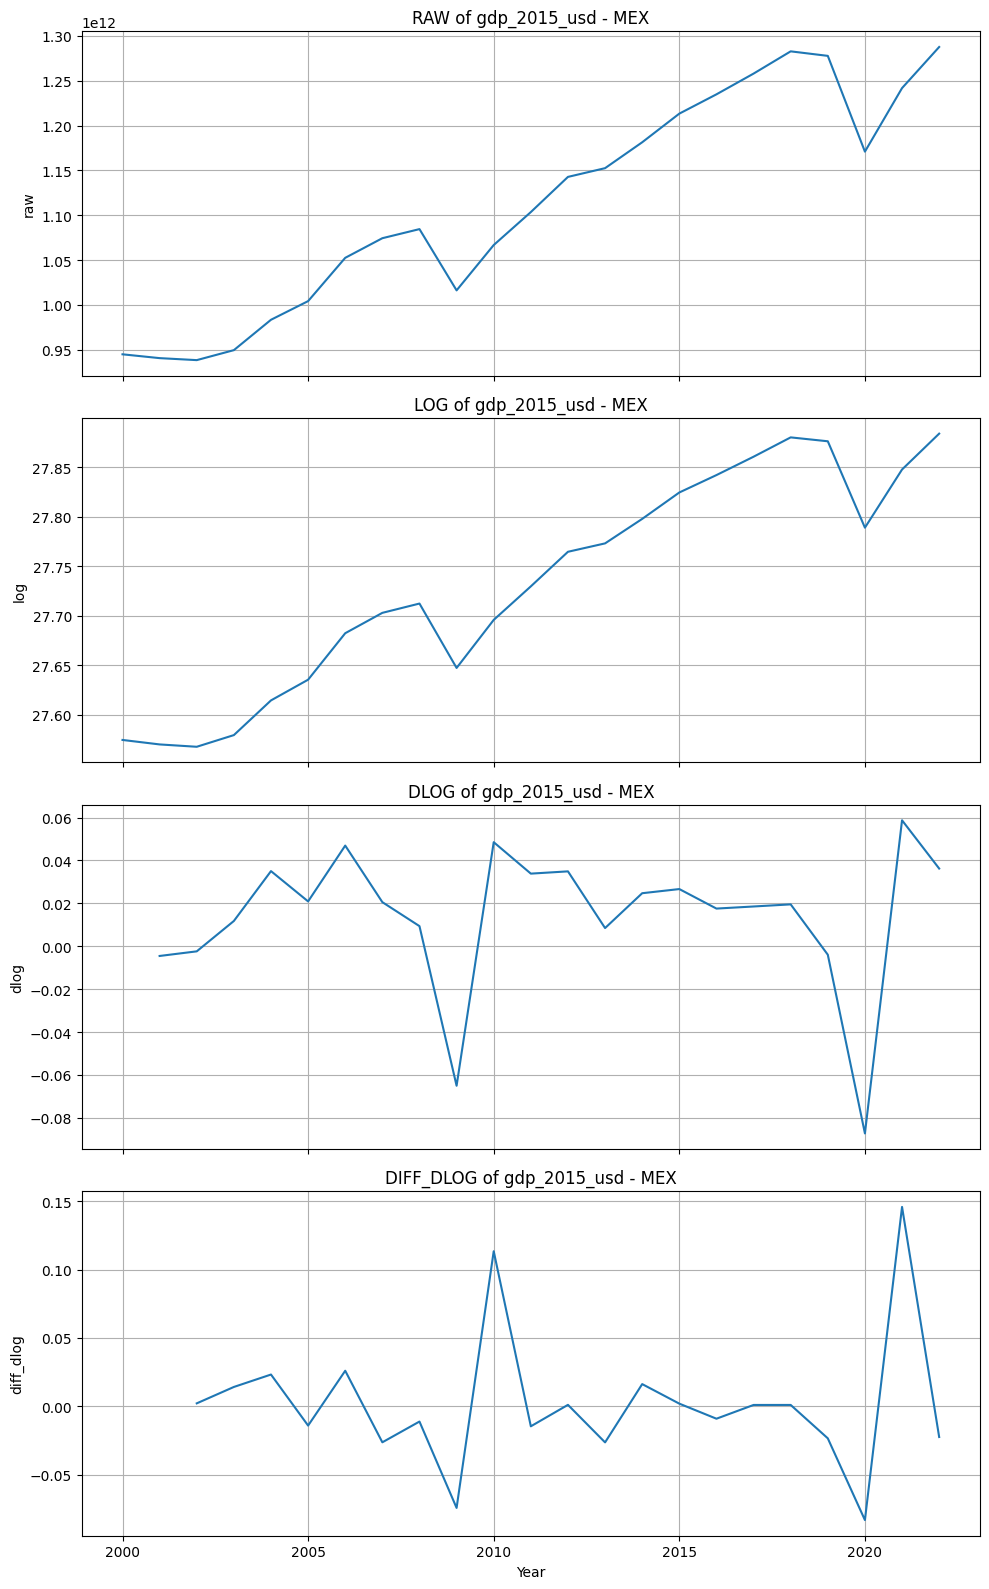

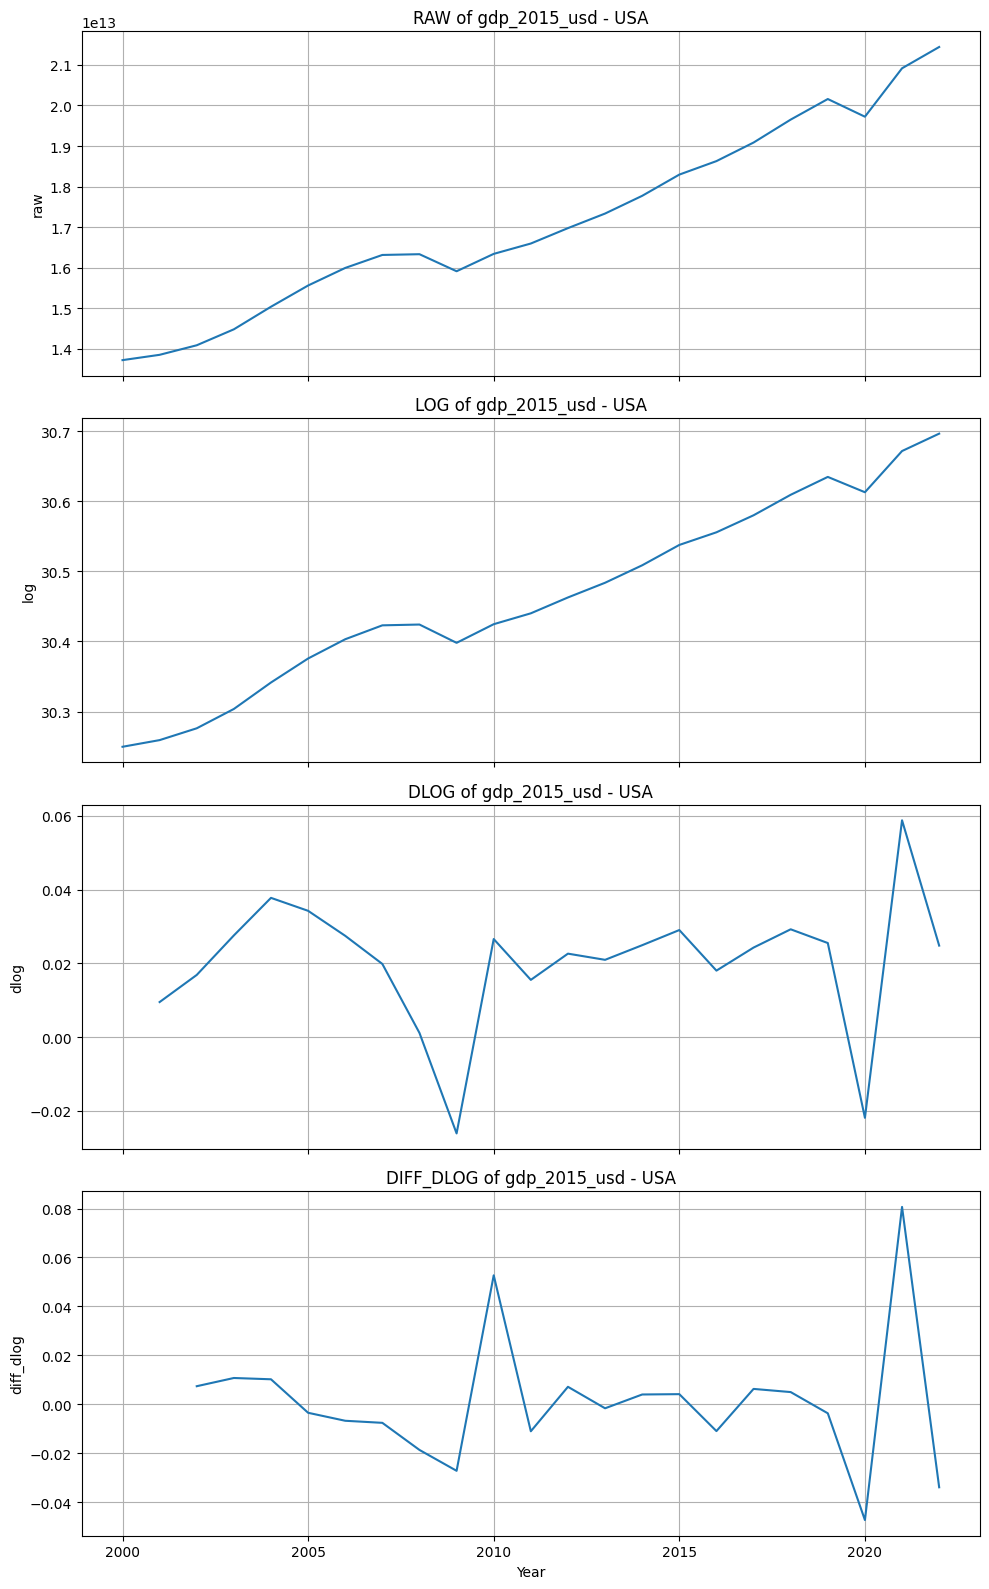

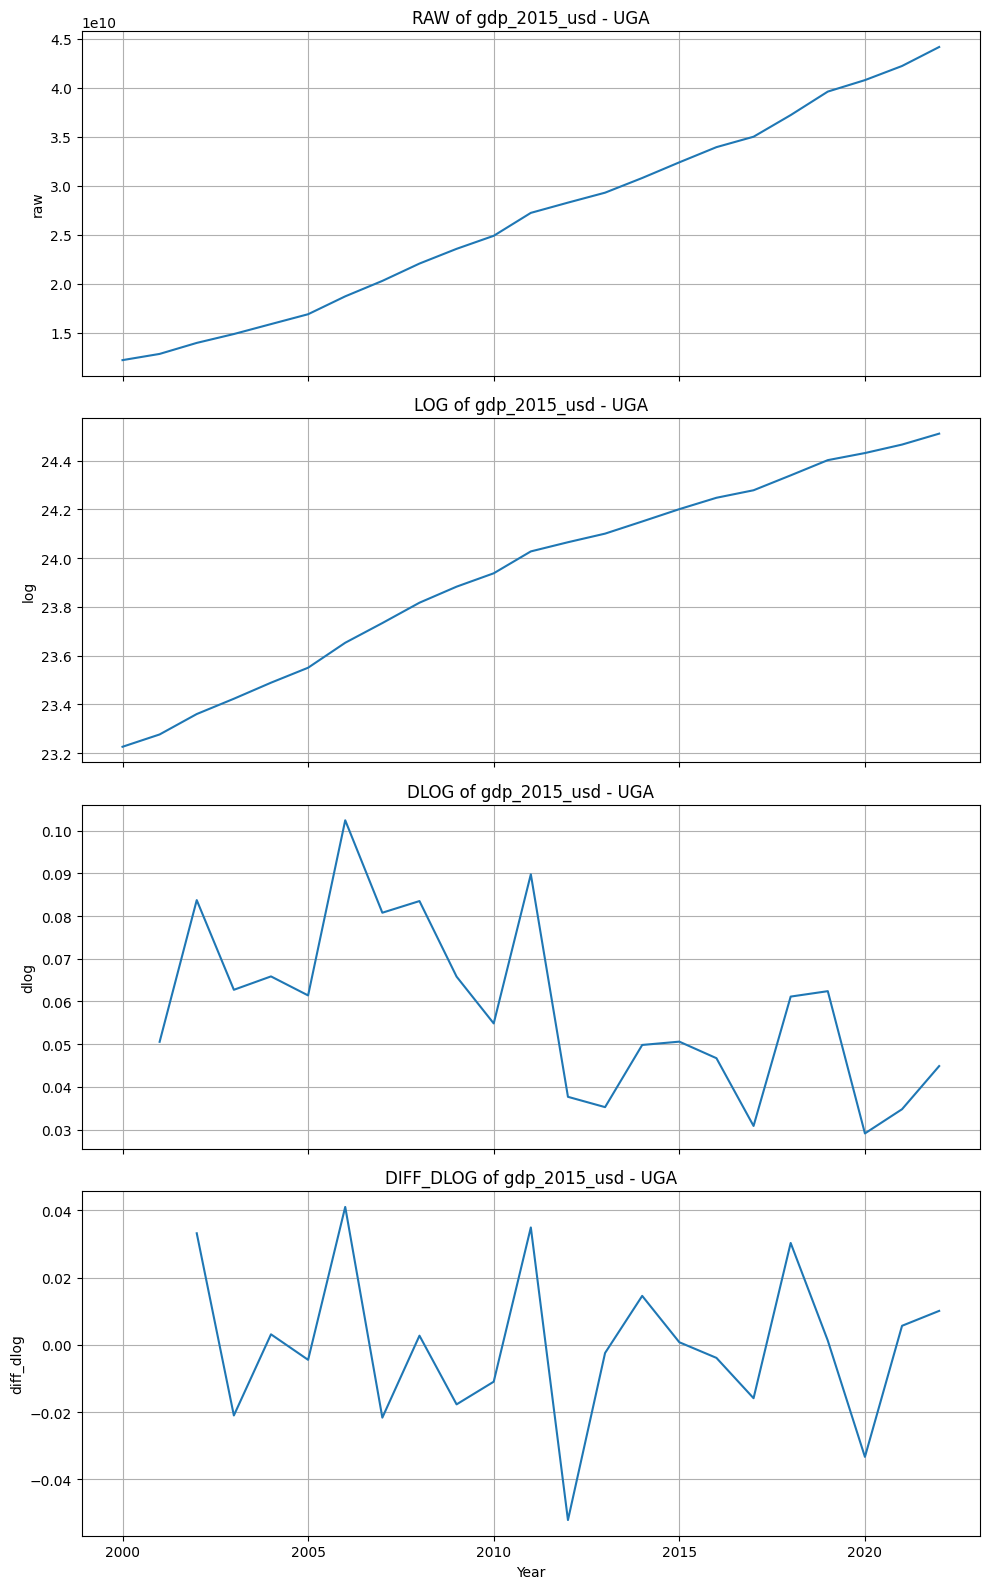

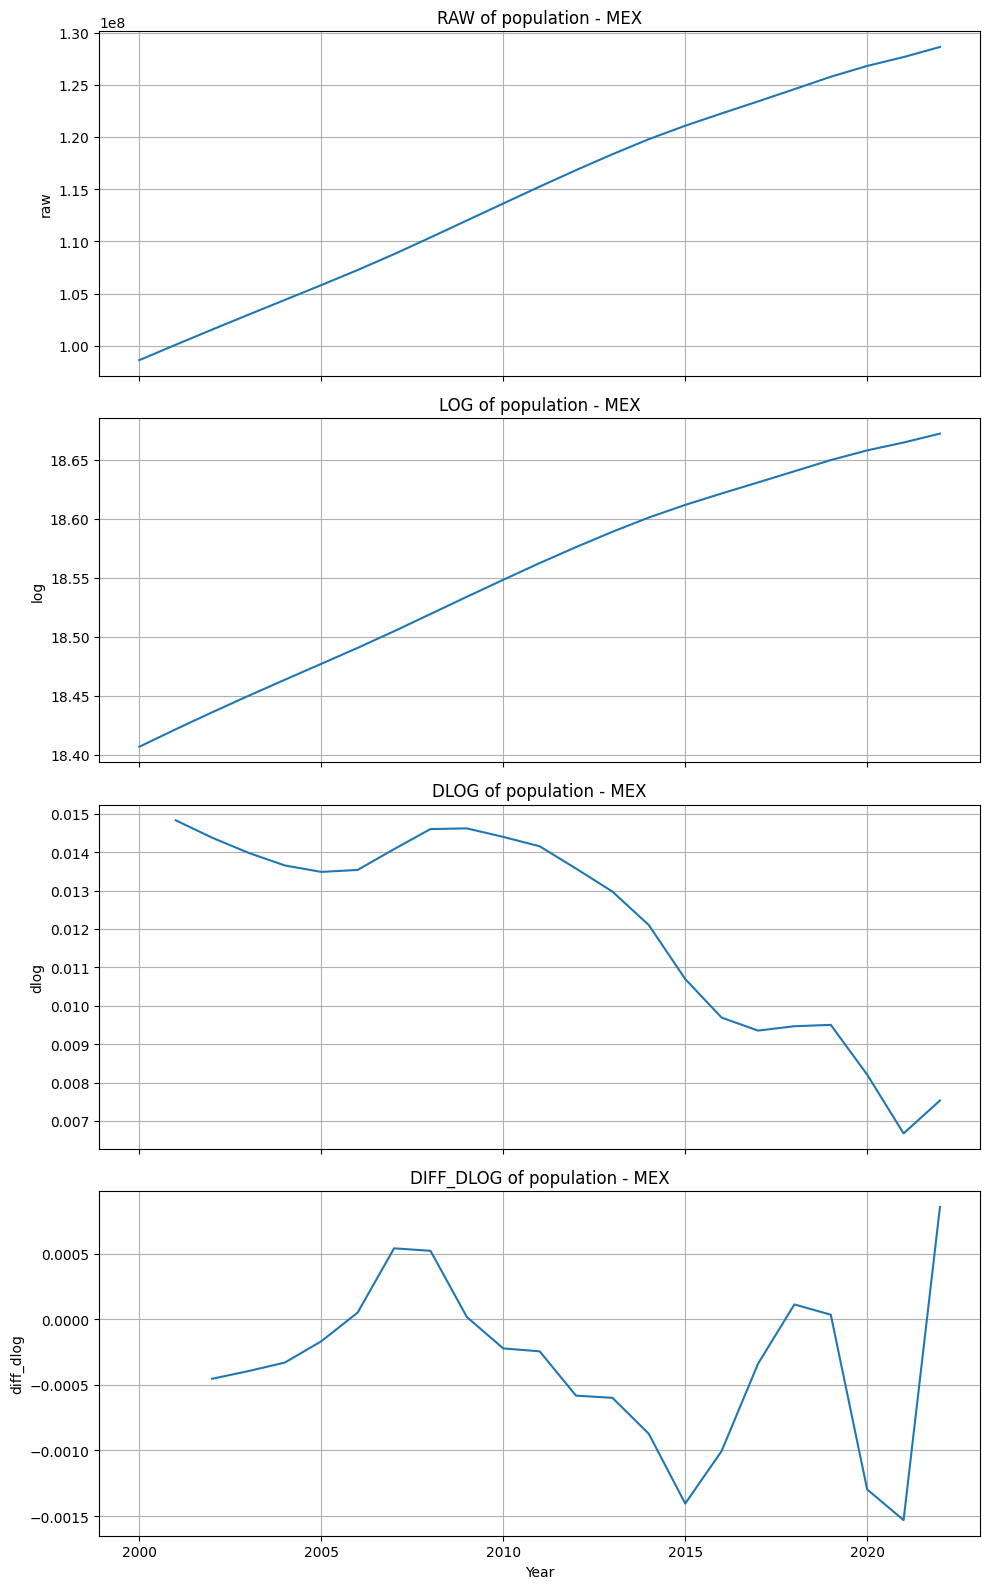

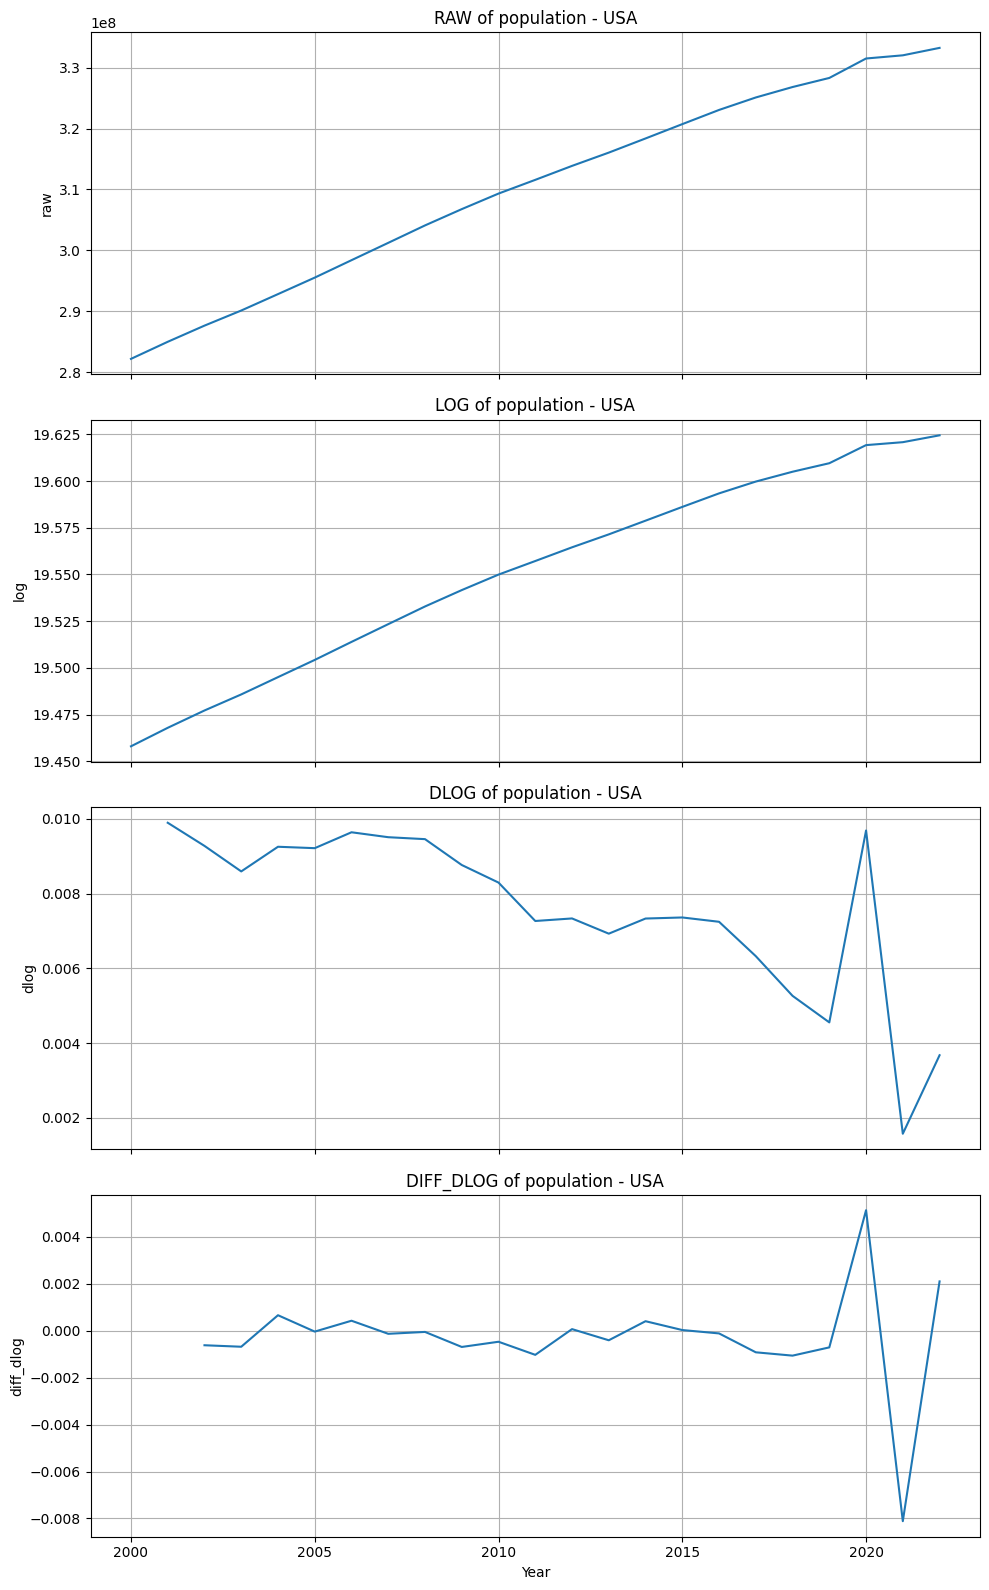

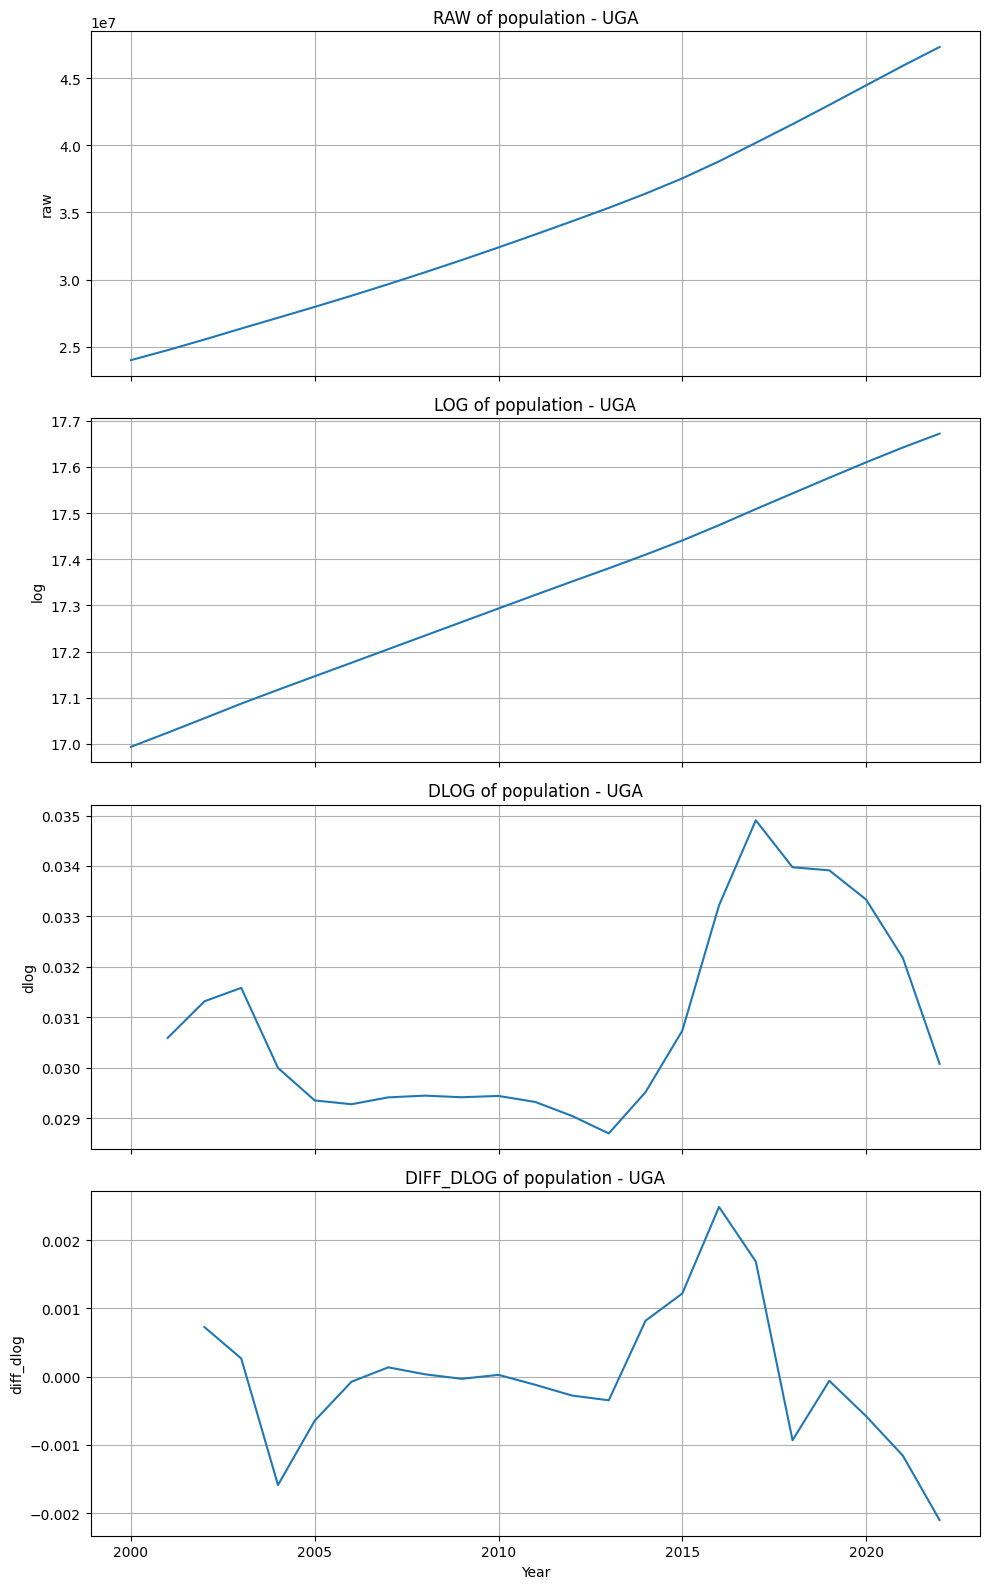

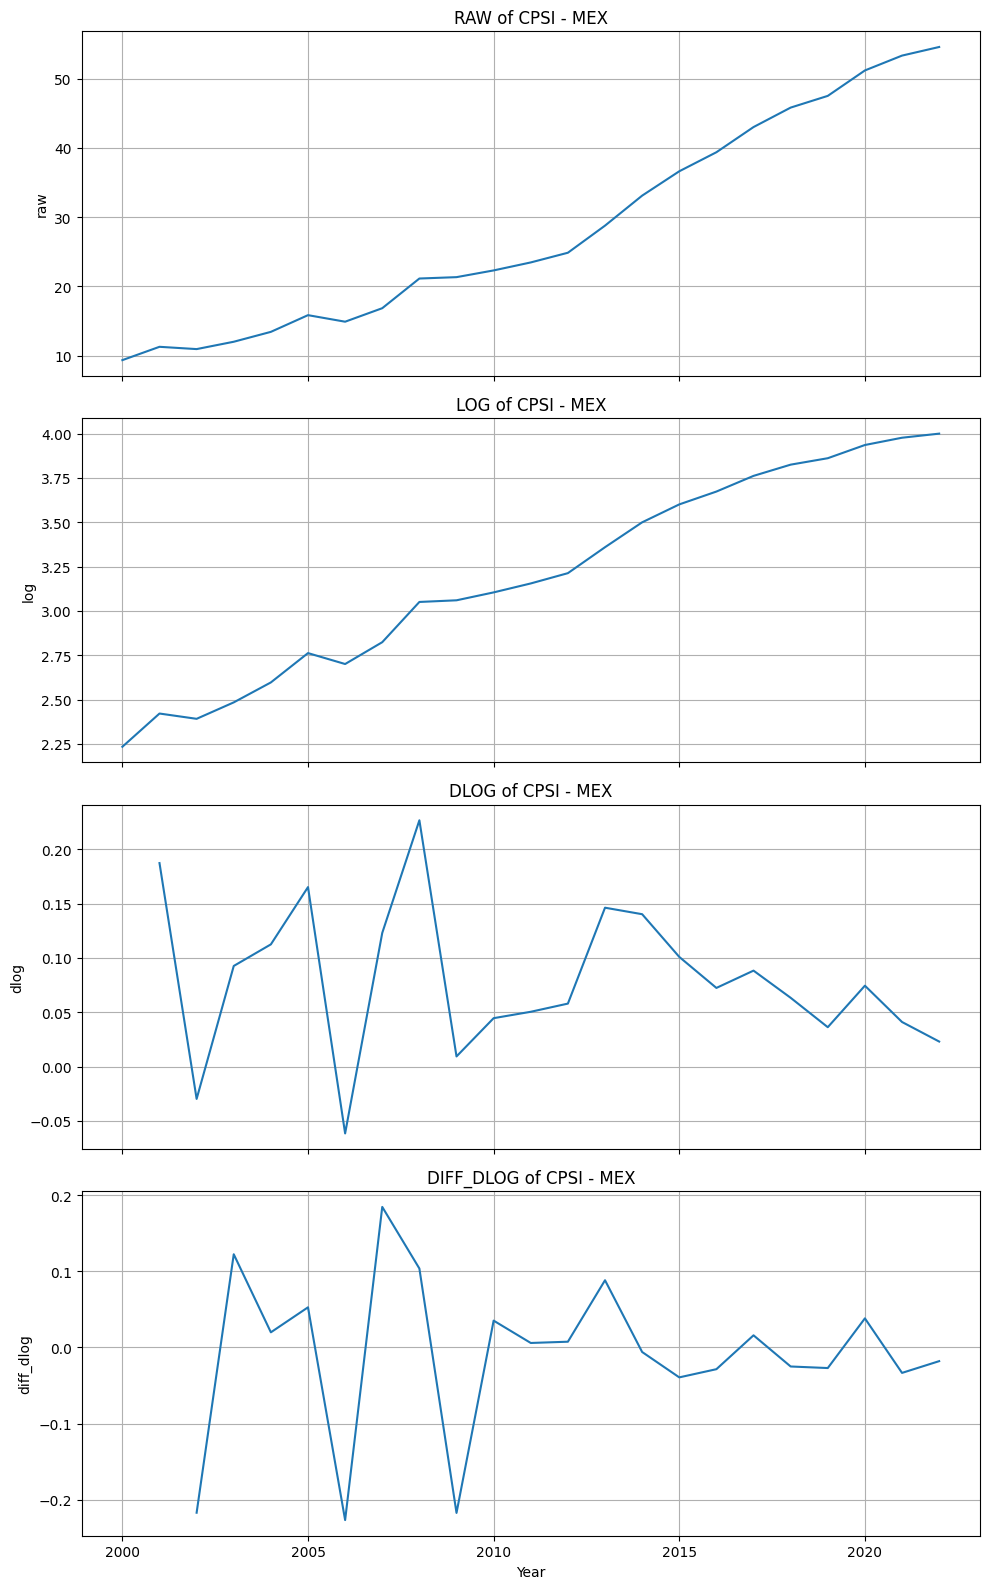

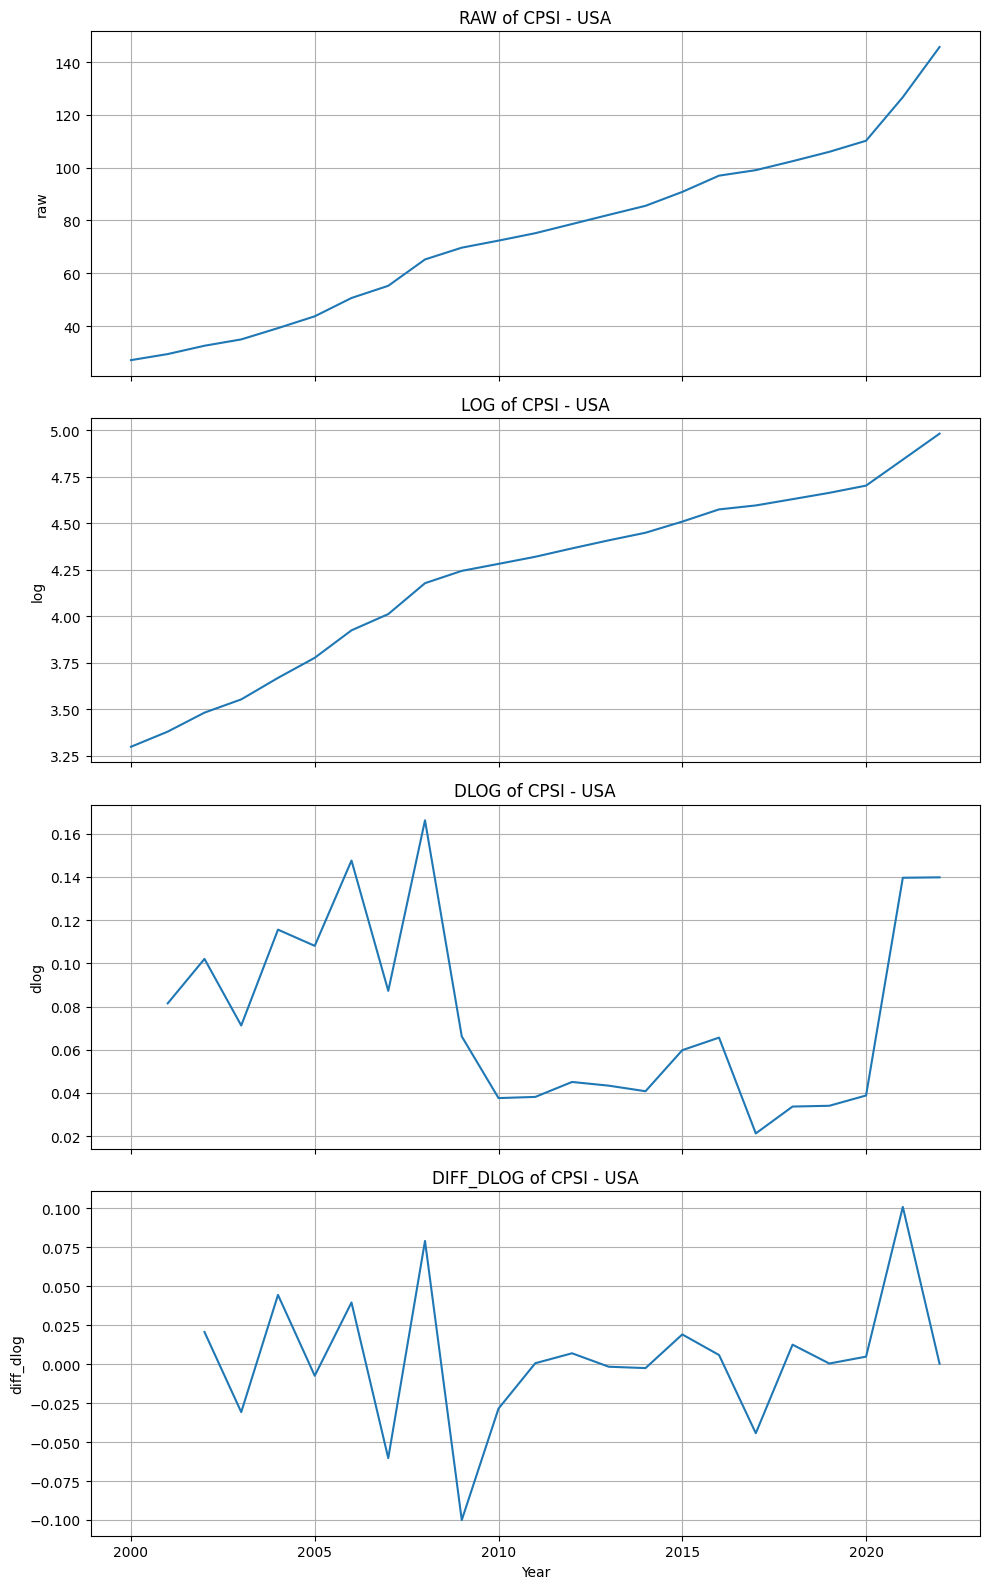

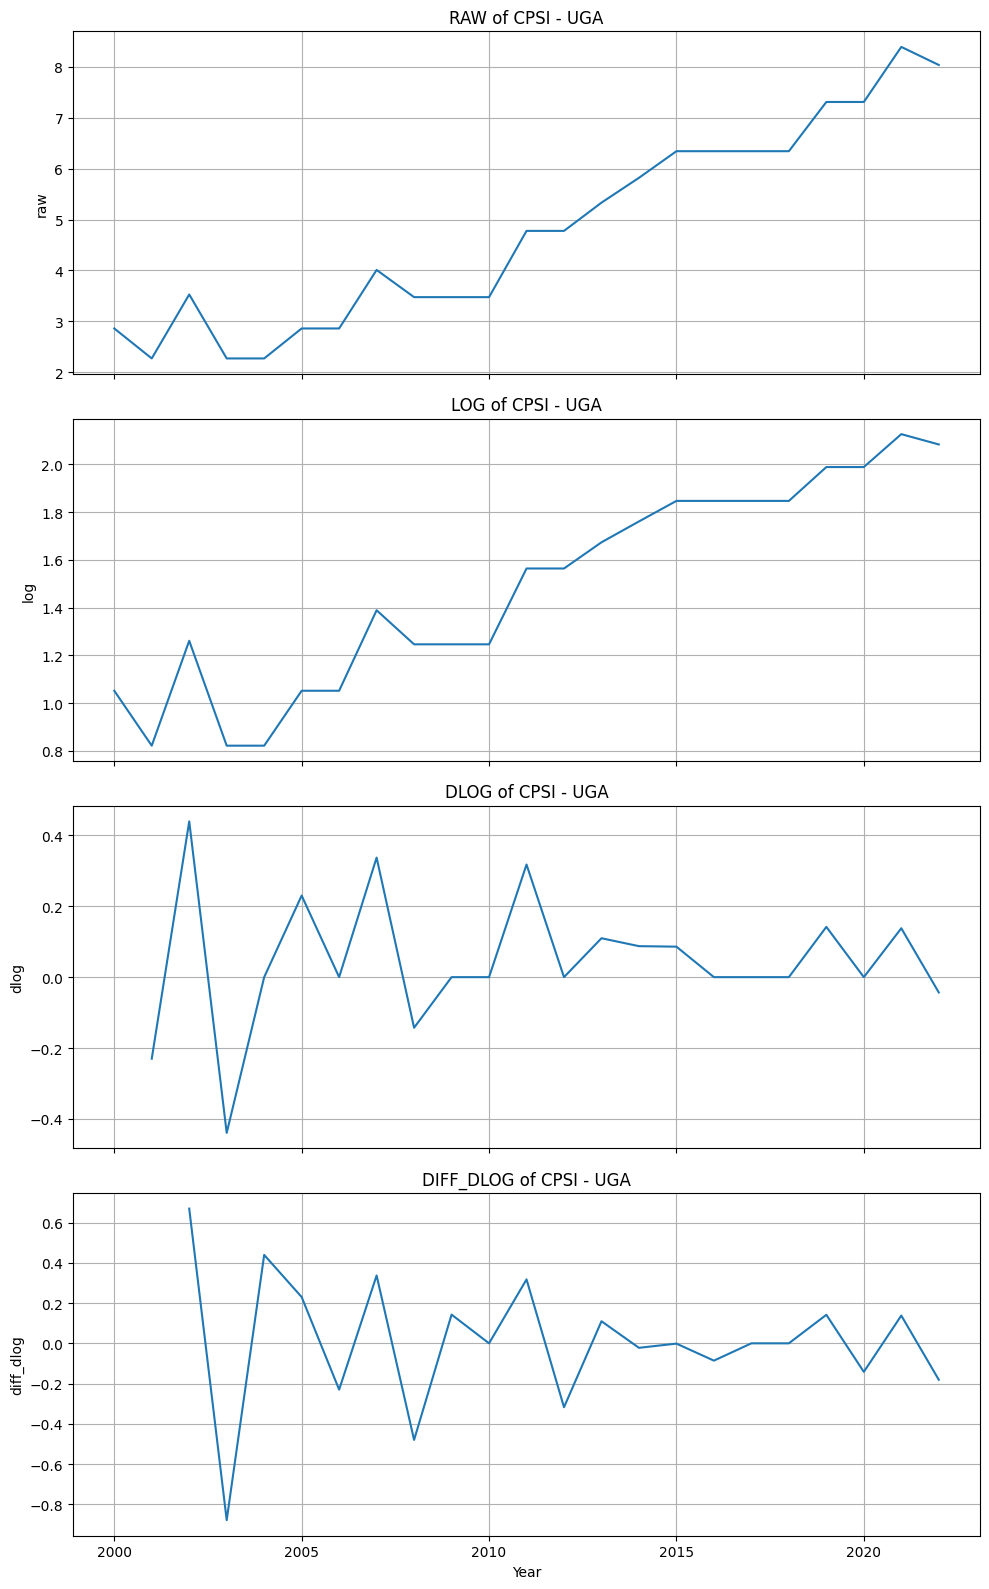

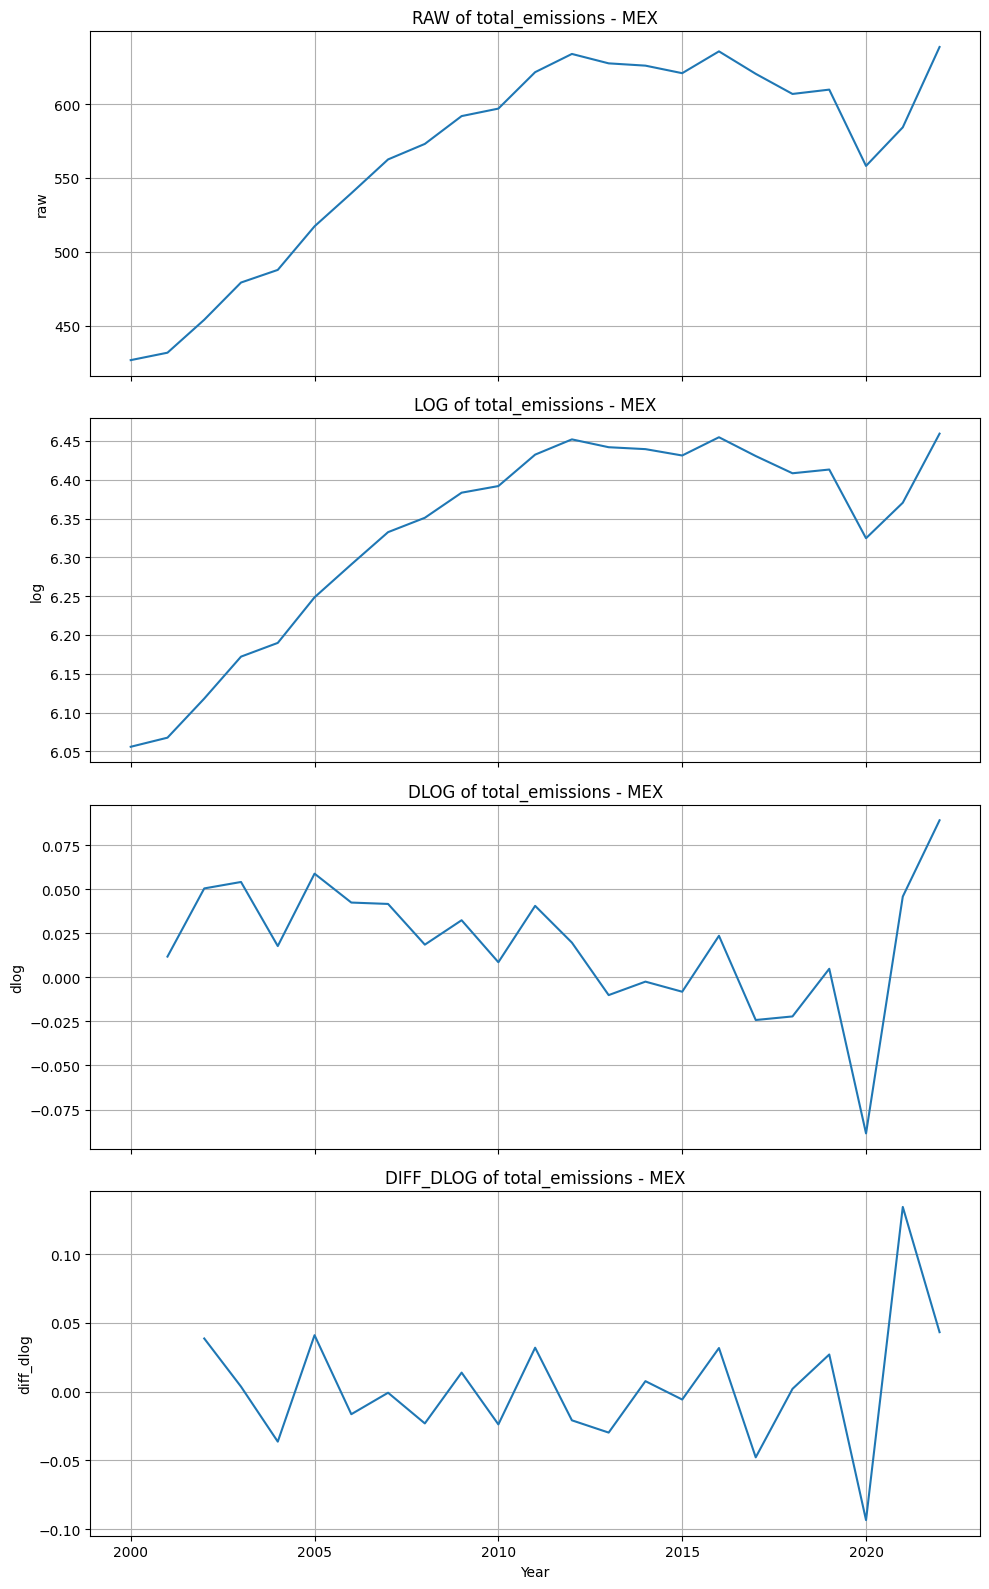

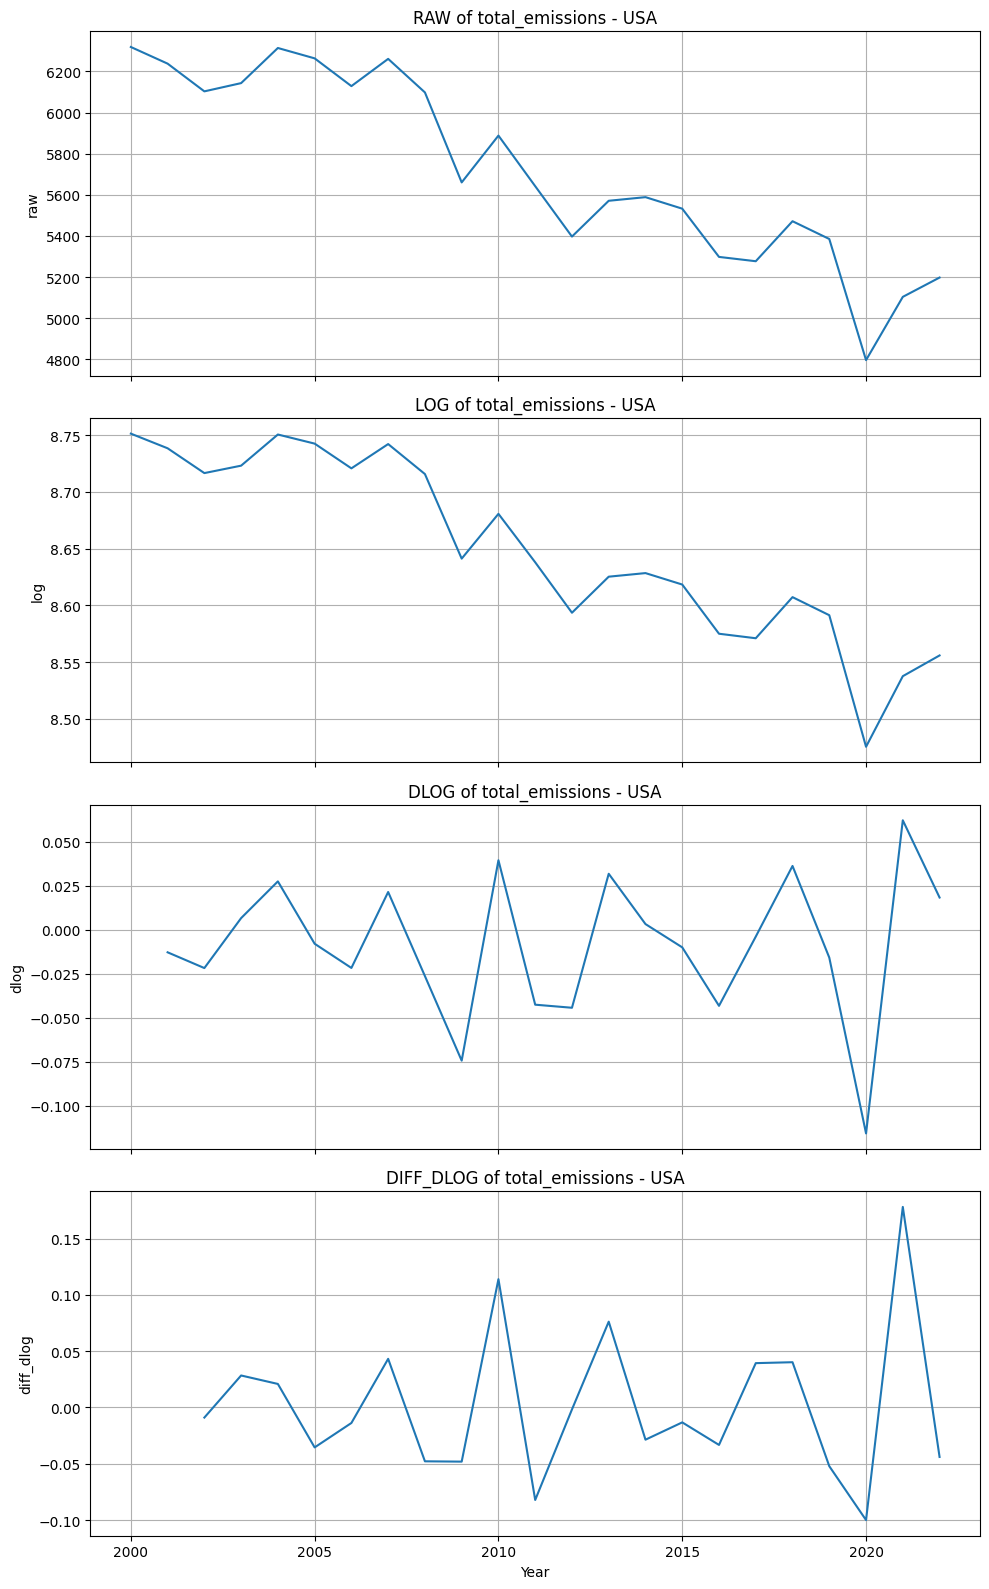

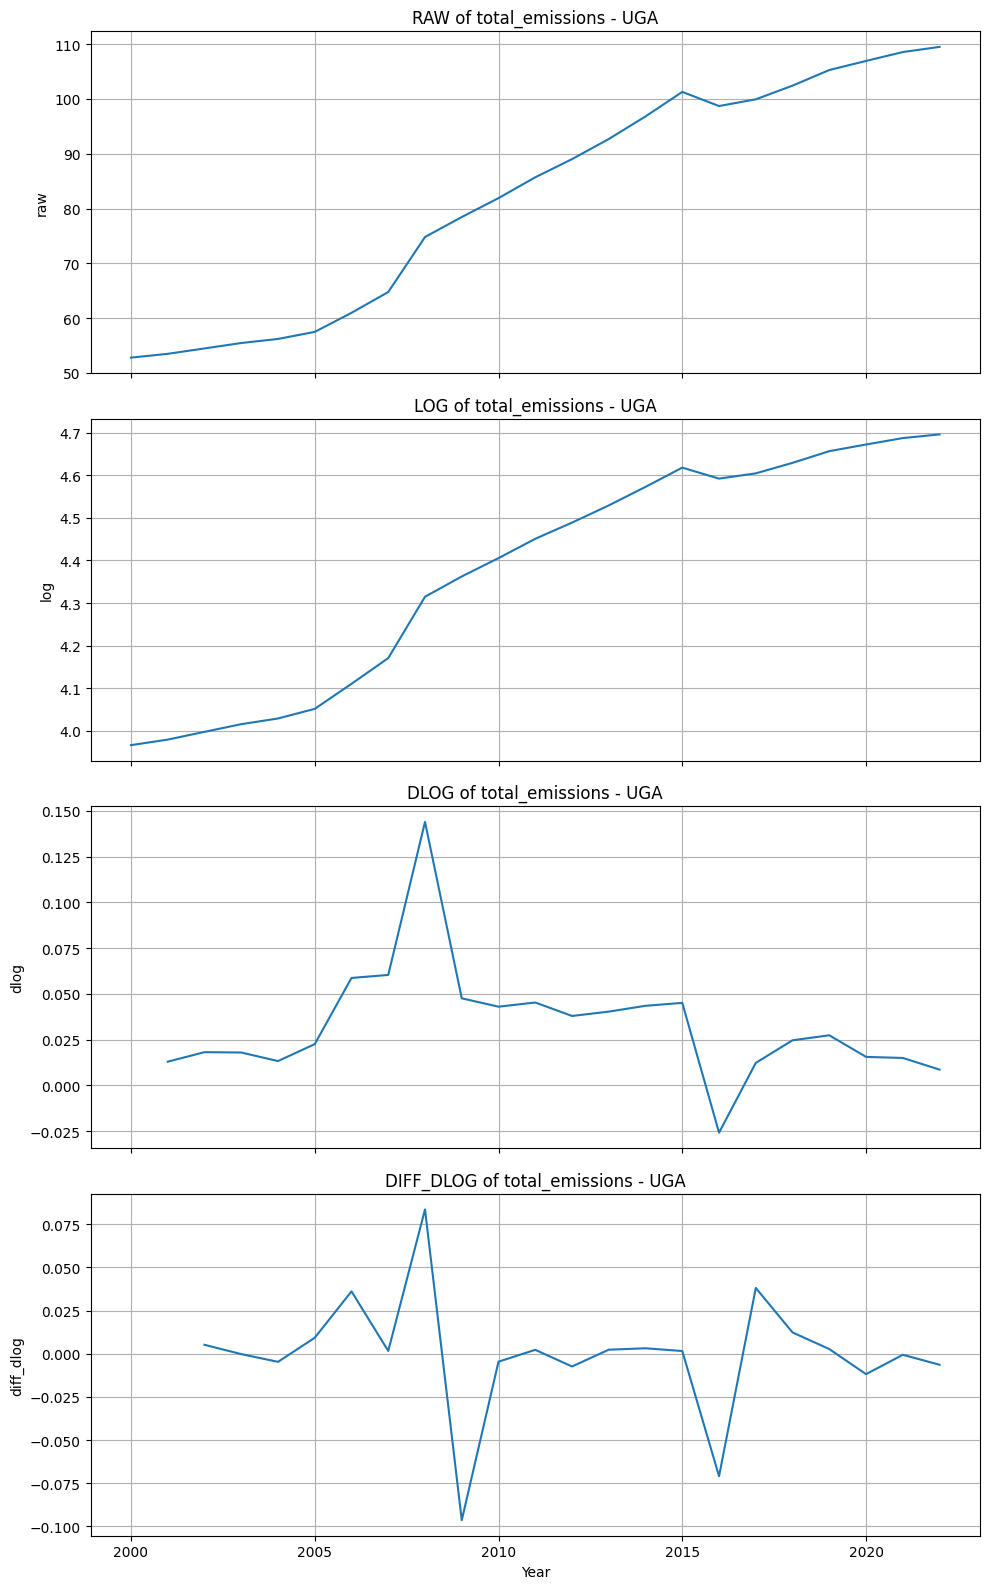

In [40]:
edp.plot_series("gdp_2015_usd", ['MEX', 'USA', 'UGA'], transformed=True)
edp.plot_series("population", ['MEX', 'USA', 'UGA'], transformed=True)
edp.plot_series("CPSI", ['MEX', 'USA', 'UGA'], transformed=True)
edp.plot_series("total_emissions", ['MEX', 'USA', 'UGA'], transformed=True)

In [46]:
edp.adf_kpss_test_summary("gdp_2015_usd", global_policy_emissions_df.iso_alpha_3.unique().tolist())

<string>:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

<string>:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

<string>:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

<string>:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

<string>:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

<string>:31: InterpolationWarning: The test statistic is outside of the range of p-values available 

,iso_alpha_3,ADF p-value raw,KPSS p-value raw,passed_ADF_raw,passed_KPSS_raw,ADF p-value log,KPSS p-value log,passed_ADF_log,passed_KPSS_log,ADF p-value dlog,KPSS p-value dlog,passed_ADF_dlog,passed_KPSS_dlog,ADF p-value diff_dlog,KPSS p-value diff_dlog,passed_ADF_diff_dlog,passed_KPSS_diff_dlog
0,AFG,0.306961,0.023494,False,False,0.023694,0.022743,True,False,1.000000e+00,0.029720,False,False,1.470761e-08,0.100000,True,True
1,AGO,0.176097,0.022767,False,False,0.017087,0.023688,True,False,9.893707e-01,0.023109,False,False,9.404267e-05,0.100000,True,True
2,ALB,0.559244,0.010000,False,False,0.506271,0.010000,False,False,1.999430e-01,0.100000,False,True,4.002951e-03,0.041667,True,False
3,ARE,0.934671,0.015963,False,False,0.370576,0.016823,False,False,1.585767e-02,0.100000,True,True,2.948612e-03,0.100000,True,True
4,ARG,0.705294,0.031911,False,False,0.701264,0.034064,False,False,6.641138e-01,0.100000,False,True,1.852054e-10,0.047029,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,VNM,0.998247,0.015818,False,False,0.593123,0.014905,False,False,7.082850e-03,0.100000,True,True,1.955726e-08,0.100000,True,True
148,YEM,0.426423,0.100000,False,True,0.407120,0.100000,False,True,5.229938e-03,0.068028,True,True,9.963028e-01,0.100000,False,True
149,ZAF,0.273376,0.018676,False,False,0.064212,0.019605,False,False,4.968755e-03,0.033040,True,False,5.505579e-03,0.041667,True,False
150,ZMB,0.095817,0.015737,False,False,0.179074,0.016680,False,False,2.317261e-06,0.055587,True,True,5.699782e-01,0.100000,False,True
